# changePoint — Wie die Pipeline funktioniert

**Leitfrage:** Sagt der *Text* einer Ad-hoc-Meldung die unmittelbare Kursreaktion vorher?

Dieses Notebook führt Schritt für Schritt durch die Pipeline. Als roter Faden dient **eine
einzige Meldung** — die Ad-hoc der Wacker Neuson SE vom 02.12.2025 —, die wir vom
Rohdatensatz über die Kursdaten und die Reaktions-KPIs bis zum Label verfolgen. Danach zoomen
wir heraus: alle 527 Meldungen, der Modellvergleich und eine Live-Demo.

Alle Zellen laufen aus den bereits gespeicherten Daten (`new_dataset/`): kein API-Aufruf, kein
Training.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

EXAMPLE_ID = "80c9e5ec7972bd49daf2f563fe4639dfddd46d5b"  # Wacker Neuson SE — WAC.XETRA — 02.12.2025 14:05

## 1. Der Datensatz

Grundlage sind 527 Ad-hoc-Meldungen aus einem liquiden Universum (2022–2026); der Korpus liegt
fertig bei (`new_dataset/adhoc_functioning.json`), es muss nichts gescrapt werden. Jede Meldung
enthält Text (Titel, Zusammenfassung), Emittenten-Metadaten (ISIN, Ticker, Börse) und den
Veröffentlichungszeitpunkt. Wir wählen unser Beispiel — Wacker Neuson (WAC.XETRA) — und sehen uns
seine Felder an. *Prof-Konzept: Datenqualität schlägt Modellkomplexität.*

In [2]:
from new_dataset.pipeline.dataset import load_records

records = load_records()
recs = {r["id"]: r for r in records}
df = pd.DataFrame([{"ticker": r["ticker"], "company": r["company"],
                    "published_local": r["published_local"]} for r in records])
print(f"Meldungen: {len(records)}  |  Zeitraum: "
      f"{df['published_local'].min()[:10]} – {df['published_local'].max()[:10]}")
print("Börsen:", df["ticker"].str.rsplit(".", n=1).str[-1].value_counts().head().to_dict())

ex = recs[EXAMPLE_ID]
print(f"\nBeispiel: {ex['company']} ({ex['ticker']})  {ex['published_local']}")
print("Titel  :", ex["title"])
print("Summary:", (ex.get("summary") or "")[:300])

Meldungen: 527  |  Zeitraum: 2022-01-03 – 2026-06-29
Börsen: {'XETRA': 506, 'SW': 15, 'F': 3, 'US': 3}

Beispiel: Wacker Neuson SE (WAC.XETRA)  2025-12-02T14:05:00
Titel  : Wacker Neuson SE bestätigt Gespräche zu Mehrheitserwerb und Übernahme durch Doosan Bobcat Inc.
Summary: Wacker Neuson SE / Schlagwort(e): Firmenübernahme Wacker Neuson SE bestätigt Gespräche zu Mehrheitserwerb und Übernahme durch Doosan Bobcat Inc. 02.12.2025 / 14:05 CET/CEST Veröffentlichung einer Insiderinformation nach Artikel 17 der Verordnung (EU) Nr. 596/2014, übermittelt durch EQS News – ein Se


## 2. Kursdaten: EODHD-Intraday

Zu jeder Meldung liegen 5-Minuten-Kursdaten in einem ±96h-Fenster vor. Wir laden sie aus dem
lokalen Cache, rechnen sie in die Zeitzone der Börse um und behalten nur Handelszeit-Bars.
*Prof-Konzept: reproduzierbare Datenpipeline, Umgang mit fehlenden Werten.*

In [3]:
from new_dataset.pipeline.eodhd_prices import load_or_fetch
from new_dataset.pipeline.exchanges import get_exch, to_exchange_hours

exch = get_exch(ex["ticker"])
bars = load_or_fetch(ex)                 # liest den Cache (kein API-Aufruf)
bars_exch = to_exchange_hours(bars, exch)
print(f"Börse: {exch['name']}  {exch['open']}–{exch['close']}  {exch['tz']}")
print(f"Bars in Handelszeit: {len(bars_exch)}")
bars_exch.head()

Börse: XETRA  (9, 0)–(17, 30)  Europe/Berlin
Bars in Handelszeit: 612


,Open,High,Low,Close,Volume
datetime,,,,,
2025-11-28 09:00:00,18.959999,19.000000,18.940000,18.940000,NaN
2025-11-28 09:05:00,18.899999,18.899999,18.899999,18.899999,100.0
2025-11-28 09:10:00,18.959999,19.040000,18.940000,18.940000,2337.0
2025-11-28 09:15:00,18.899999,18.959999,18.840000,18.959999,689.0
2025-11-28 09:20:00,18.940000,18.979999,18.879999,18.879999,281.0


## 3. Slot-Methodik & Reaktions-KPIs

Die Reaktion wird slot-basiert gemessen: Den Teil-Bar, der den Meldungszeitpunkt enthält,
verwerfen wir; je Horizont (5/10/15/30 Min) vergleichen wir $k = N/5$ Bars vor und nach der
Meldung (Preis Punkt-zu-Punkt, Volumen als Slot-Summe). Für Wacker Neuson fällt die 10-Minuten-Preis-
reaktion sehr deutlich positiv aus. *Prof-Konzept: zeitkorrekte Konstruktion ohne Lookahead,
Feature Engineering.*

In [4]:
from new_dataset.pipeline.slots import slot_change, HORIZONS
from new_dataset.pipeline.kpis import compute_row

news_dt = ex["news_dt"]
rows = []
for m in HORIZONS:
    r = slot_change(bars_exch, news_dt, m)
    rows.append({"Horizont": f"{m} Min",
                 "Preis Δ%": None if r is None else round(r[0], 2),
                 "Volumen Δ%": None if r is None else round(r[1], 1)})
display(pd.DataFrame(rows))

kpi = compute_row(ex, bars_exch)
print("Sofort-Δ:", kpi.get("sofort_delta_pct"), "%   |   "
      "10-Min-Preis-Δ:", kpi.get("price_delta_pct_10m"), "%")

,Horizont,Preis Δ%,Volumen Δ%
0,5 Min,12.50,342.2
1,10 Min,14.95,359.7
2,15 Min,15.93,429.6
3,30 Min,14.71,58.7
4,60 Min,14.95,-14.1


Sofort-Δ: 12.500005514706135 %   |   10-Min-Preis-Δ: 14.950986027009105 %


## 4. Der ±24h-Chart

Die Detailgrafik stellt zwei Handelstage nebeneinander: mit klarem Schnitt, Kurs- und
Volumenverlauf, einer KPI-Box und der Overnight-Gap-Annotation. Entscheidend ist die
news-zeit-abhängige Wahl der Panels. Wacker Neuson wurde um 14:05 veröffentlicht, also in der
**zweiten Tageshälfte**. Deshalb zeigt der Chart **Meldungstag → nächster Handelstag**, damit
die weiterlaufende Reaktion sichtbar bleibt und nicht am rechten Rand abgeschnitten wird.
*Prof-Konzept: sorgfältige, zeitkorrekte Datenaufbereitung und Visualisierung (Wunsch aus der
Betreuer-E-Mail).*

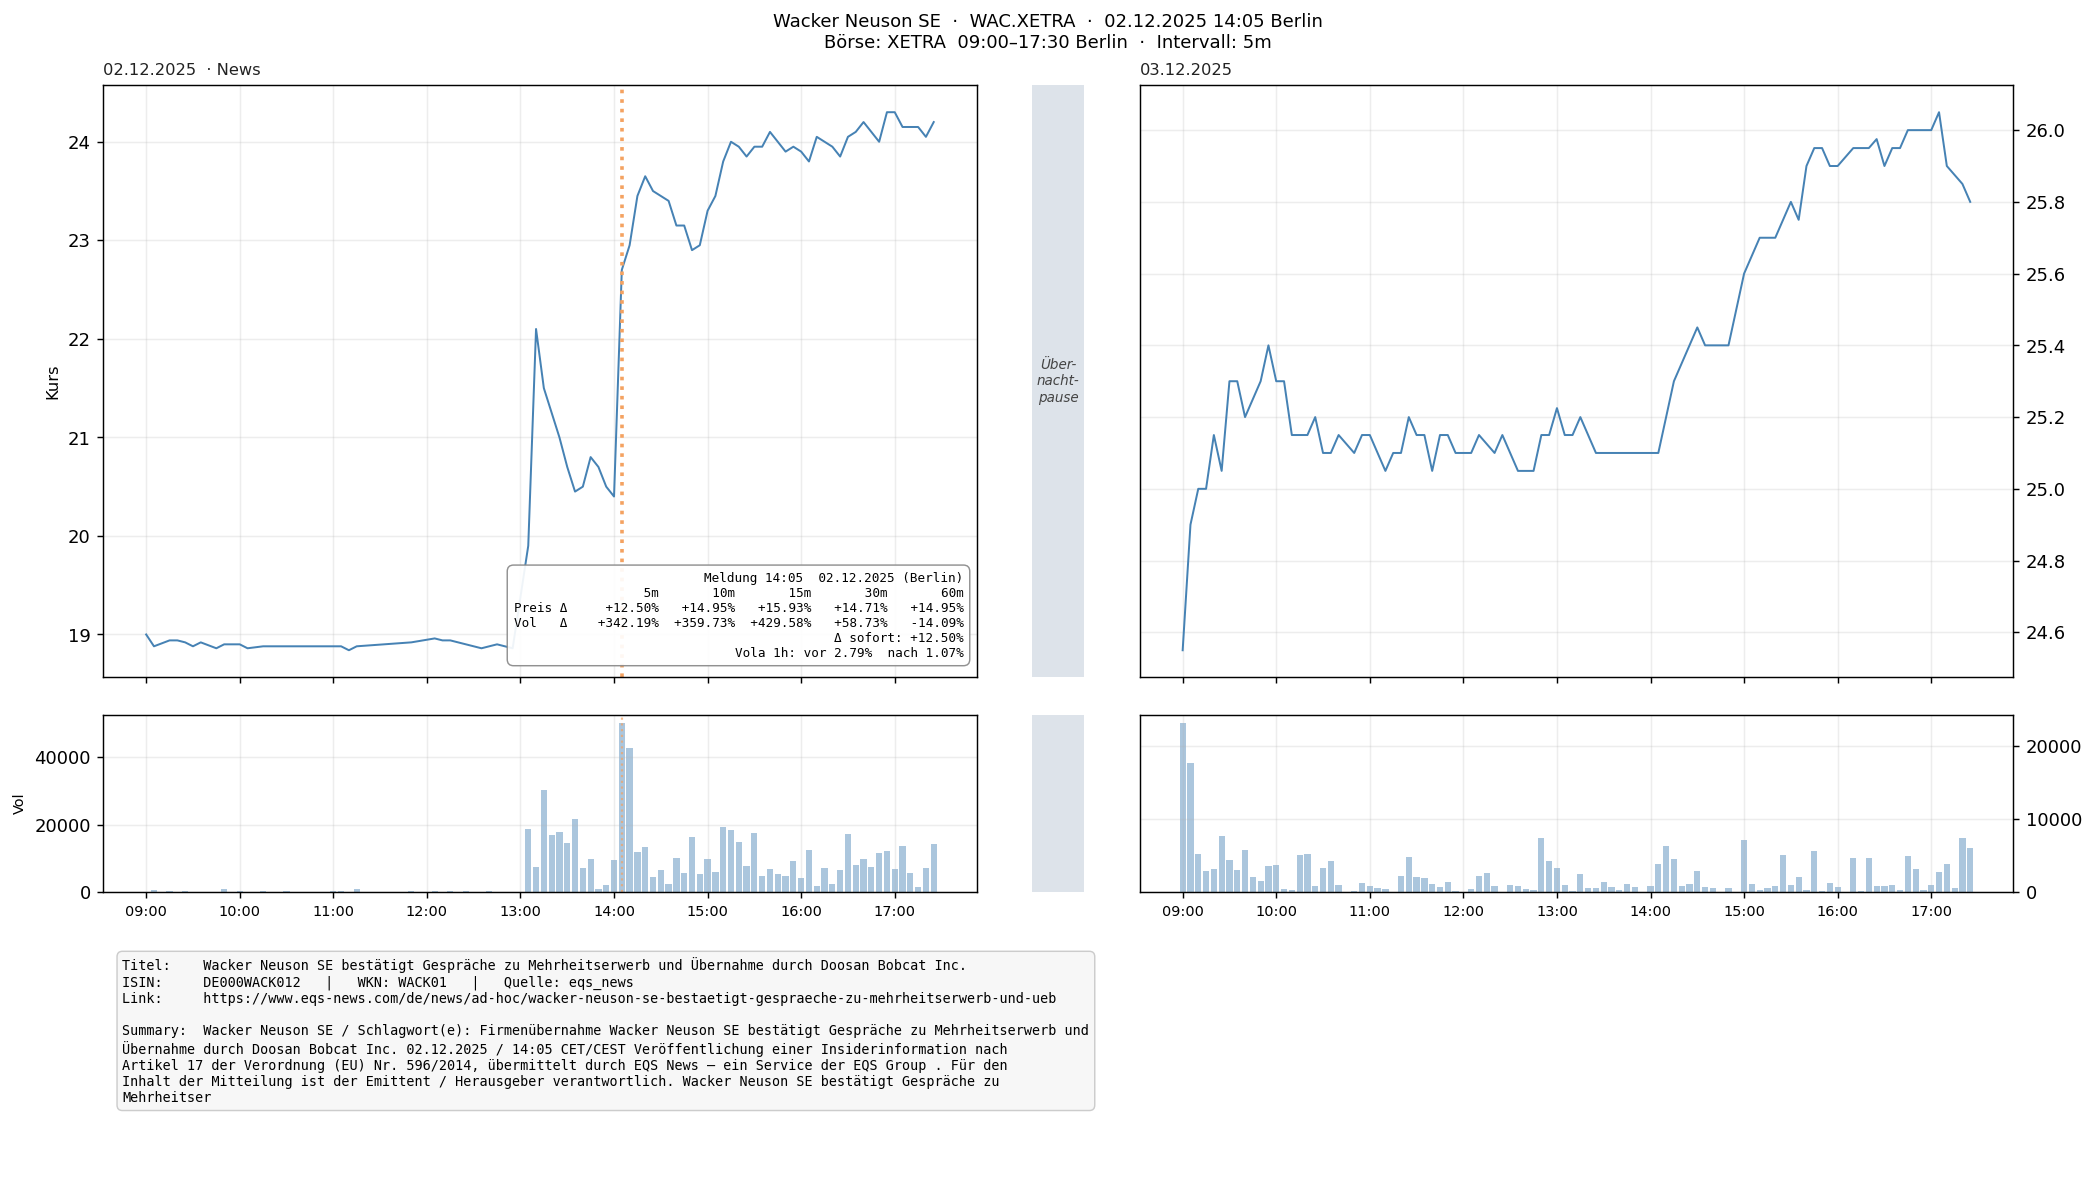

In [5]:
p = Path(f"new_dataset/charts/{EXAMPLE_ID}.png")
display(Image(str(p))) if p.exists() else print("Chart fehlt:", p)

## 5. Das Label: Auf / Ab / Flat

Aus der 10-Minuten-Kursreaktion leiten wir ein 3-Klassen-Label ab: Auf (> +0,1 %),
Ab (< −0,1 %) oder Flat (dazwischen; eps = 0,1 %). Wacker Neuson fällt klar in „Auf“. Über alle
527 Meldungen ist die Verteilung unausgewogen, mit deutlich mehr „Auf“ als „Flat“. *Prof-Konzept:
Multi-Klassen-Klassifikation, Klassenungleichgewicht sichtbar machen.*

In [6]:
from collections import Counter
from new_dataset.pipeline.labels import label_3class, build_labeled

lab = label_3class(kpi["price_delta_pct_10m"])
print(f"Label des Beispiels (Δ10m = {kpi['price_delta_pct_10m']} %): {lab}")

dist = Counter(it["label"] for it in build_labeled())
print("Klassenverteilung (alle Meldungen):", dict(dist))

Label des Beispiels (Δ10m = 14.950986027009105 %): up
Klassenverteilung (alle Meldungen): {'down': 190, 'flat': 30, 'up': 307}


## 6. Reaktion über alle Meldungen

Das Streudiagramm trägt die prozentuale Kursreaktion gegen die Volumenreaktion (10-Minuten-
Horizont) für alle Meldungen ab. Zwischen fertigem Sentiment und Reaktion besteht nur ein
schwacher Zusammenhang (Spearman ρ ≈ 0,03). *Prof-Konzept: Korrelation ≠ Kausalität, robuste
Rangkorrelation.*

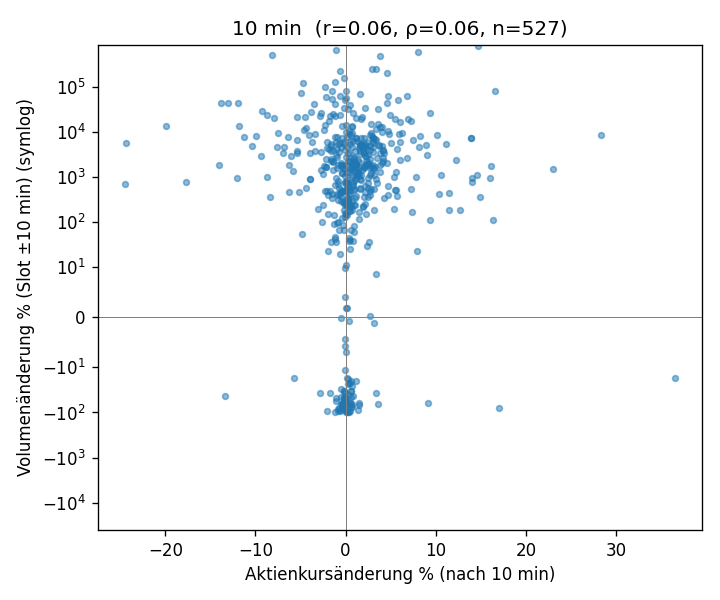

In [7]:
p = Path("new_dataset/scatter/scatter_10min.png")
display(Image(str(p))) if p.exists() else print("Scatter fehlt:", p)

## 7. Modelle & Ergebnisse

Wir vergleichen fünf Modelle — von der Majority-Baseline über klassische Modelle auf
German-FinBERT-Embeddings bis zum fine-getunten Modell —, bewertet mit Macro-F1 (nicht Accuracy,
wegen der Imbalance). Kernbefund: fertiges Off-the-shelf-Sentiment liegt nahe der Baseline, die
**gelernten Embeddings** tragen mit logistischer Regression (`logreg_embed`) jedoch das stärkste
Signal (Test-Macro-F1 ≈ 0,48 gegenüber 0,25 der Baseline). *Prof-Konzept: F1 statt Accuracy, Baselines zuerst,
leakage-sicherer Test.*

,Modell,CV Macro-F1,CV Std,Test Macro-F1,Test Accuracy,Majority-Baseline
0,majority,0.2451,0.0,0.2473,0.5897,0.5897
1,★ logreg_embed,0.4922,0.0032,0.4821,0.5897,0.5897
2,rf_embed,0.4648,0.0214,0.3765,0.5897,0.5897
3,pretrained_sentiment,0.3832,0.0,0.3506,0.4359,0.5897
4,finetuned_finbert,0.4167,0.0176,0.4785,0.5897,0.5897


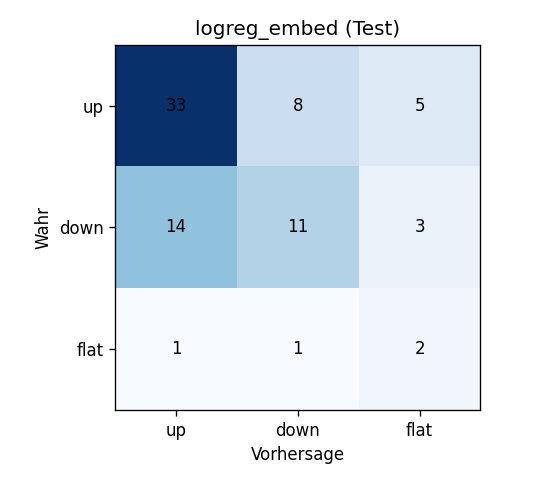

In [8]:
from new_dataset.dashboard.data import model_results_table

display(model_results_table())
p = Path("new_dataset/model_eval/confusion_logreg_embed.png")
display(Image(str(p))) if p.exists() else print("Konfusionsmatrix fehlt:", p)

## 8. Live-Demo

Das persistierte beste Modell (`logreg_embed`) sagt aus dem Meldungstext die Reaktionsrichtung
vorher. **Hinweis:** Diese Zelle benötigt den ML-Stack (torch/transformers) und den
Modell-Speicher `new_dataset/model_store/`. Das interaktive Dashboard startet man mit
`python -m new_dataset.dashboard.app`.

In [9]:
# Hinweis: benötigt den ML-Stack (torch/transformers) + new_dataset/model_store/.
from new_dataset.pipeline import persist

text = ex["title"] + " " + (ex.get("summary") or "")
pred = persist.predict([text])[0]
if "proba" in pred:
    print("Vorhergesagte Reaktion:", pred["label"],
          "| P:", {k: round(v, 2) for k, v in pred["proba"].items()})
else:
    print(pred.get("note"))
# Dashboard starten:  python -m new_dataset.dashboard.app

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: scherrmann/GermanFinBERT_SC_Sentiment
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vorhergesagte Reaktion: up | P: {np.str_('down'): 0.28, np.str_('flat'): 0.3, np.str_('up'): 0.42}


## 9. Zusammenfassung & Reproduktion

Der rote Faden: eine Meldung → Kursdaten → Slot-KPIs → Chart → Label; danach der Blick auf alle
Meldungen, den Modellvergleich und die Live-Vorhersage. Der ehrliche Befund bleibt differenziert:
Der Text trägt ein klares Richtungssignal (Spearman ρ ≈ 0,44), das vortrainierte Sentiment
schlägt die Baseline, und die gelernte Textrepräsentation liefert das beste Modell; die exakte
3-Klassen-Zuordnung bleibt trotzdem schwer, vor allem für die seltene Flat-Klasse.
Reproduktion der gesamten Pipeline (News liegen bei, es wird nichts gescrapt):

- `python -m new_dataset.pipeline.build`: Kursdaten aus dem Cache, KPIs, Charts, Scatter.
- `python -m new_dataset.pipeline.rerender`: Charts mit news-zeit-abhängiger Session-Wahl.
- `python -m new_dataset.pipeline.figures`: alle Abbildungen und Tabellen.
- `python -m new_dataset.pipeline.train`: Modellvergleich (`model_results.csv`; braucht requirements-ml).
- `python -m new_dataset.pipeline.persist`: bestes Modell für die Live-Demo speichern.
- `python -m new_dataset.sentiment_reaction`: Korrelation Sentiment ↔ Reaktion.
- `python -m new_dataset.dashboard.app`: interaktives Dashboard.